In [1]:
import pickle
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
sns.set()
sns.set_theme(style='whitegrid')
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [2]:
display_name = {'FedAvg': 'LS(FedAvg)', 'Tche': 'TCH', 'AFL': 'OMDgd-TCH(AFL)', 'AFLeg': 'OMDeg-TCH',
                'AFL_new': 'AdaOMDgd-TCH', 'AFLeg_new': 'AdaOMDeg-TCH'}
colors = {'FedAvg': 'r', 'Tche': 'darkgray', 
          'AFL': 'b', 'AFL_new': 'c', 'AFLeg': 'm', 'AFLeg_new': 'plum'}

In [3]:
def plot_curves(ds_name, allocation_scheme, seeds, methods, mode=2, ymin=0., ymax=2.5):
    
    fig, axs = plt.subplots(1, 2, figsize=(15, 6))
    # axins = [inset_axes(axs[0], width="30%", height="30%"),
    #          inset_axes(axs[1], width="30%", height="30%")]

    for method in methods:
        avg_training_loss, avg_test_loss = [], []

        for seed in seeds:
            path = f'../output/10seeds/{ds_name}_{allocation_scheme}/seed{seed}/{method}/log.pickle'
            with open(path, 'rb') as file:
                res = pickle.load(file)
            commu_round = np.arange(len(res))

            training_loss = [step['train_infer_stats']['mean_loss'] for step in res]
            if mode == 2:
                training_loss = [np.max(step['train_infer_stats']['losses']) for step in res]
            avg_training_loss.append(training_loss)
            
            test_loss = [step['test_infer_stats']['mean_loss'] for step in res]
            if mode == 2:
                test_loss = [np.max(step['test_infer_stats']['losses']) for step in res]
            avg_test_loss.append(test_loss)

        method_name = method.split('_llr')[0]
        display = display_name[method_name]

        train_mean = np.mean(avg_training_loss, axis=0)
        axs[0].plot(commu_round, train_mean, label=display_name[method_name], color=colors[method_name], linewidth=2.5)
        train_std = np.sqrt(np.var(avg_training_loss, axis=0))
        # axs[0].fill_between(commu_round, train_mean-train_std, train_mean+train_std, color=colors[method_name], alpha=0.2)
        
        test_mean = np.mean(avg_test_loss, axis=0)
        axs[1].plot(commu_round, test_mean, label=display_name[method_name], color=colors[method_name], linewidth=2.5)
        test_std = np.sqrt(np.var(avg_test_loss, axis=0))
        # axs[1].fill_between(commu_round, test_mean-test_std, test_mean+test_std, color=colors[method_name], alpha=0.2)
        
        # axins[0].plot(commu_round, train_mean, color=colors[method_name])
        # axins[0].fill_between(commu_round, train_mean-train_std, train_mean+train_std, color=colors[method_name], alpha=0.2)

    fig_titles = ['{} Training Loss'.format('Average' if mode==1 else 'Max'), 
                  '{} Test Loss'.format('Average' if mode==1 else 'Max')]
    
    for col_id in range(2):
        axs[col_id].set_ylim(ymin=ymin, ymax=ymax)
        axs[col_id].set_xlabel('Round', fontsize=18)
        axs[col_id].set_ylabel(fig_titles[col_id], fontsize=18)
        axs[col_id].legend(fontsize=18)

        # axins[col_id].set_xlim(250, 300)
        # axins[col_id].set_ylim(0, 0.8)
        # axins[col_id].tick_params(axis='both', which='both', length=0)
        # axins[col_id].set_xticks([])
        # axins[col_id].set_yticks([])
        # axs[col_id].indicate_inset_zoom(axins[col_id])
    
    suffix = 'seed=0' if len(seeds) == 1 else '10seeds'
    if allocation_scheme == 'rotation':
        allocation_title = 'Rotation'
    if allocation_scheme == 'partial_class_ni2':
        allocation_title = 'Partial_Class_C=2'
    elif allocation_scheme == 'partial_class_ni5':
        allocation_title = 'Partial_Class_C=5'
    fig.suptitle(f'{ds_name} {allocation_title} {suffix}', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'figures/curves/{ds_name}_{allocation_scheme}_curves_{suffix}.pdf')
    plt.show()
    plt.close()

In [4]:
def plot_train_only(ds_name, allocation_scheme, seeds, methods, mode=2, ymin=0., ymax=2.5):
    
    fig, ax = plt.subplots(figsize=(8, 6))
    # axins = [inset_axes(axs[0], width="30%", height="30%"),
    #          inset_axes(axs[1], width="30%", height="30%")]

    for method in methods:
        avg_training_loss = []

        for seed in seeds:
            path = f'../output/10seeds/{ds_name}_{allocation_scheme}/seed{seed}/{method}/log.pickle'
            with open(path, 'rb') as file:
                res = pickle.load(file)
            commu_round = np.arange(len(res))

            training_loss = [step['train_infer_stats']['mean_loss'] for step in res]
            if mode == 2:
                training_loss = [np.max(step['train_infer_stats']['losses']) for step in res]
            avg_training_loss.append(training_loss)

        method_name = method.split('_llr')[0]
        display = display_name[method_name]

        train_mean = np.mean(avg_training_loss, axis=0)
        ax.plot(commu_round, train_mean, label=display_name[method_name], color=colors[method_name], linewidth=2.5)
        train_std = np.sqrt(np.var(avg_training_loss, axis=0))
        
    fig_titles = '{} Training Loss'.format('Average' if mode==1 else 'Max')

    ax.set_ylim(ymin=ymin, ymax=ymax)
    ax.set_xlabel('Round', fontsize=18)
    ax.set_ylabel(fig_titles, fontsize=18)
    ax.legend(fontsize=18)
    
    suffix = 'seed=0' if len(seeds) == 1 else '10seeds'
    if allocation_scheme == 'rotation':
        allocation_title = 'Rotation'
    if allocation_scheme == 'partial_class_ni2':
        allocation_title = 'Partial Class C=2'
    elif allocation_scheme == 'partial_class_ni5':
        allocation_title = 'Partial Class C=5'
    fig.suptitle(f'{ds_name} {allocation_title}', fontsize=20)
    plt.tight_layout()
    plt.savefig(f'figures/curves/{ds_name}_{allocation_scheme}_curves_{suffix}_train.pdf')
    plt.show()
    plt.close()

In [5]:
seeds = [0, 25, 37, 42, 53, 81, 119, 1010, 1201, 2003]

### MNIST

#### Rotation

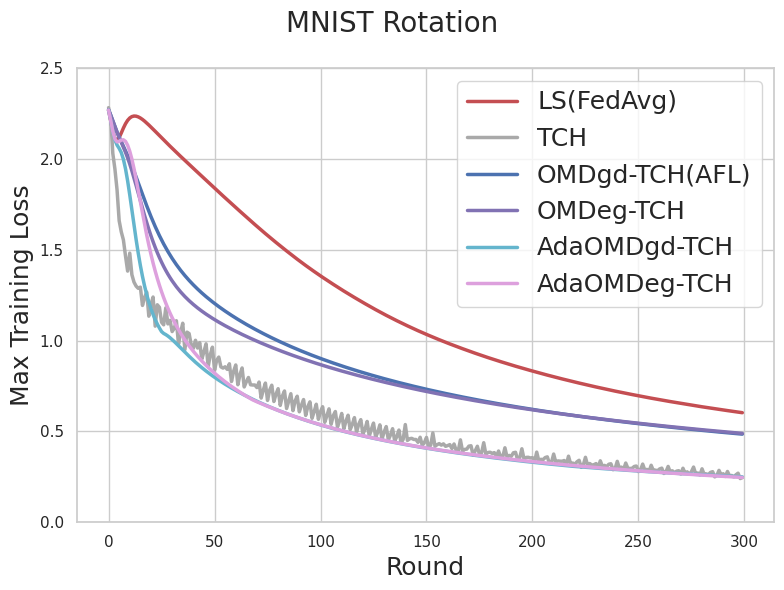

In [5]:
plot_train_only('MNIST', 'rotation', [0], 
            ['FedAvg', 'Tche', 'AFL_llr0.03', 'AFLeg_llr0.3', 'AFL_new_llr0.03', 'AFLeg_new_llr0.1'])

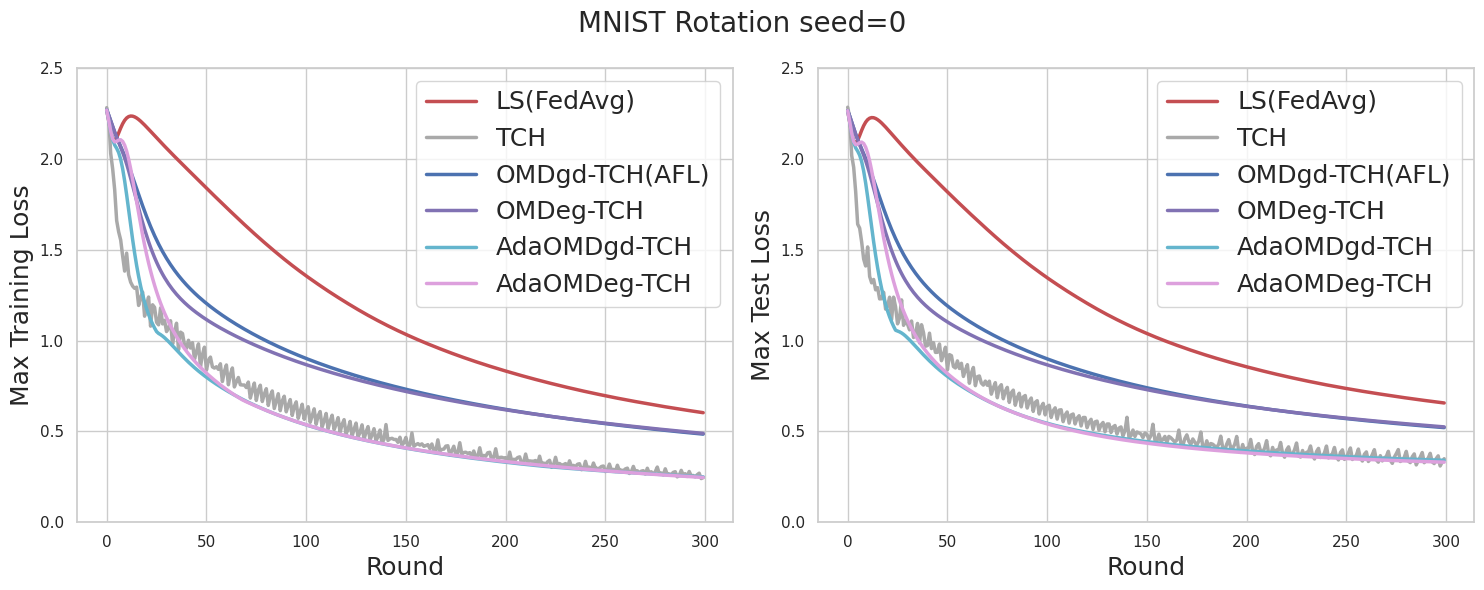

In [5]:
plot_curves('MNIST', 'rotation', [0], 
            ['FedAvg', 'Tche', 'AFL_llr0.03', 'AFLeg_llr0.3', 'AFL_new_llr0.03', 'AFLeg_new_llr0.1'])

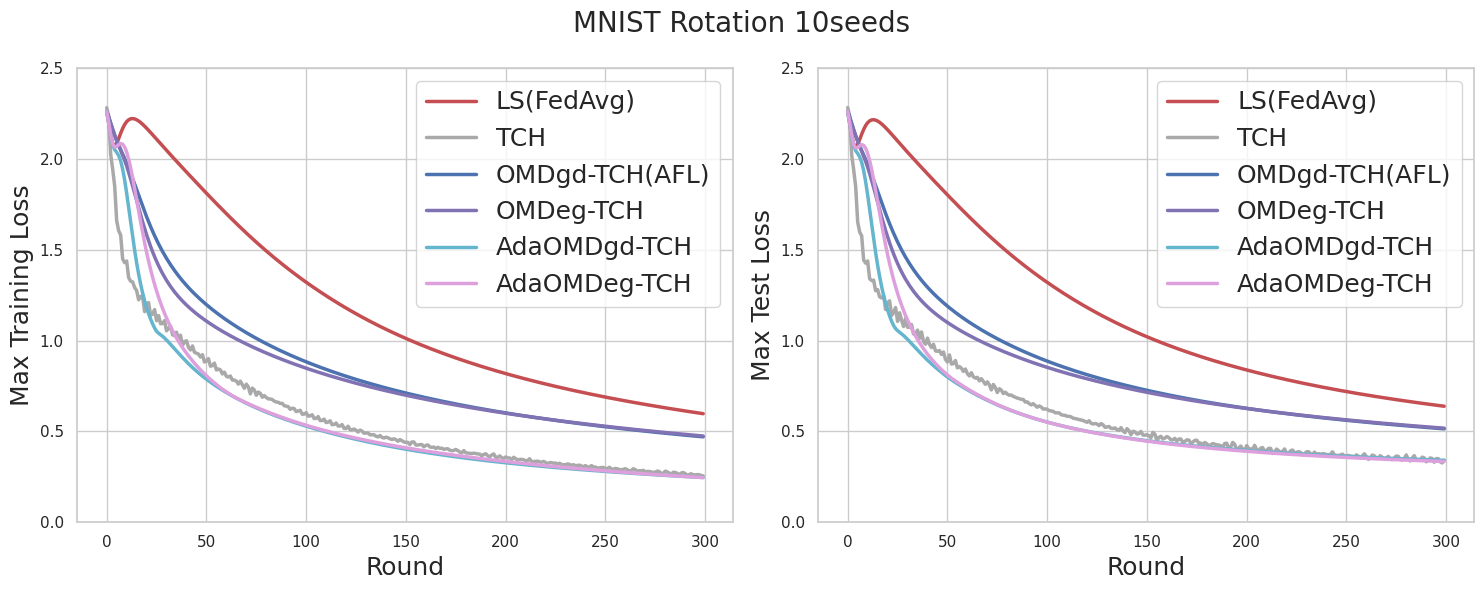

In [8]:
plot_curves('MNIST', 'rotation', seeds, 
            ['FedAvg', 'Tche', 'AFL_llr0.03', 'AFLeg_llr0.3', 'AFL_new_llr0.03', 'AFLeg_new_llr0.1'])

#### Partial_class_ni2

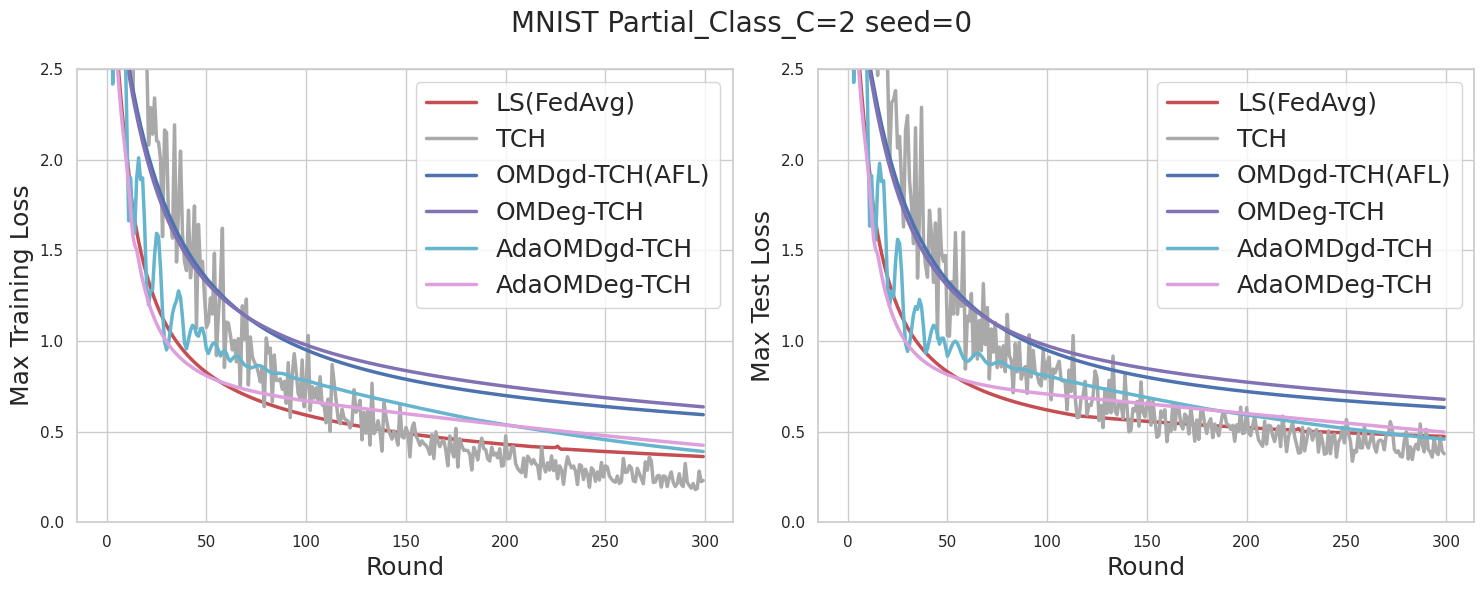

In [32]:
plot_curves('MNIST', 'partial_class_ni2', [0], 
            ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.3', 'AFL_new_llr1.0', 'AFLeg_new_llr0.3'])

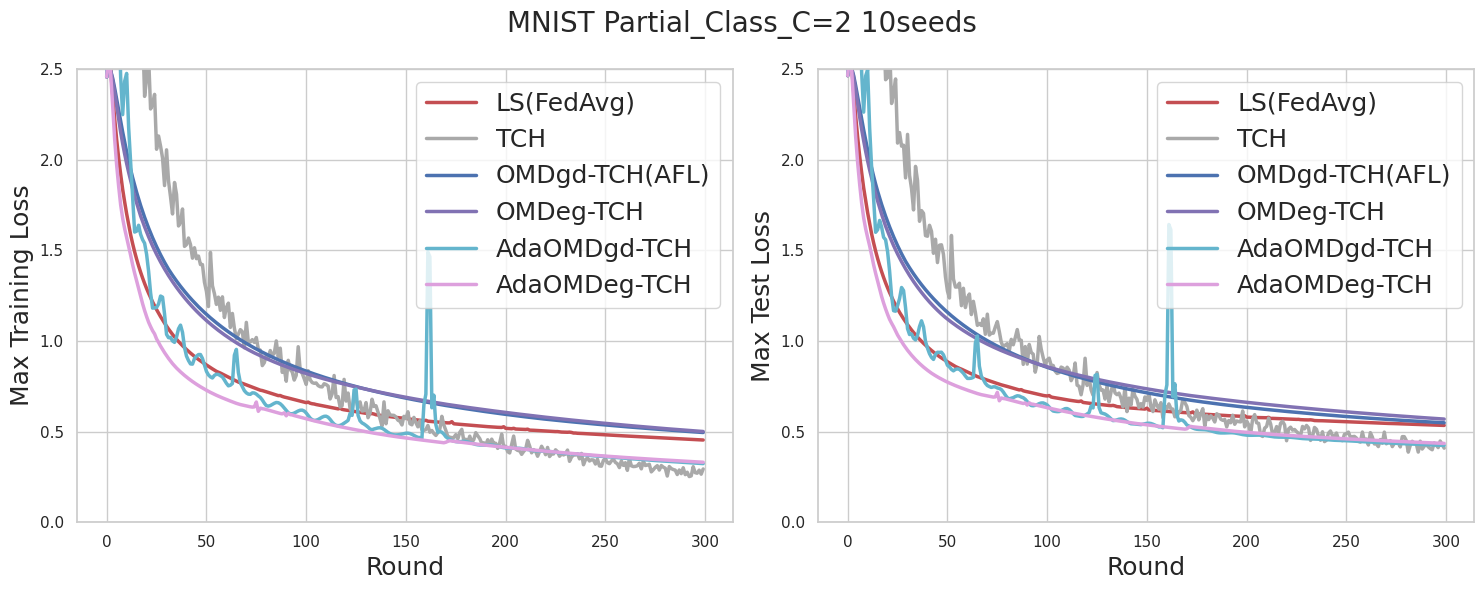

In [33]:
plot_curves('MNIST', 'partial_class_ni2', seeds, 
            ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.3', 'AFL_new_llr1.0', 'AFLeg_new_llr0.3'])

#### Partial_class_ni5

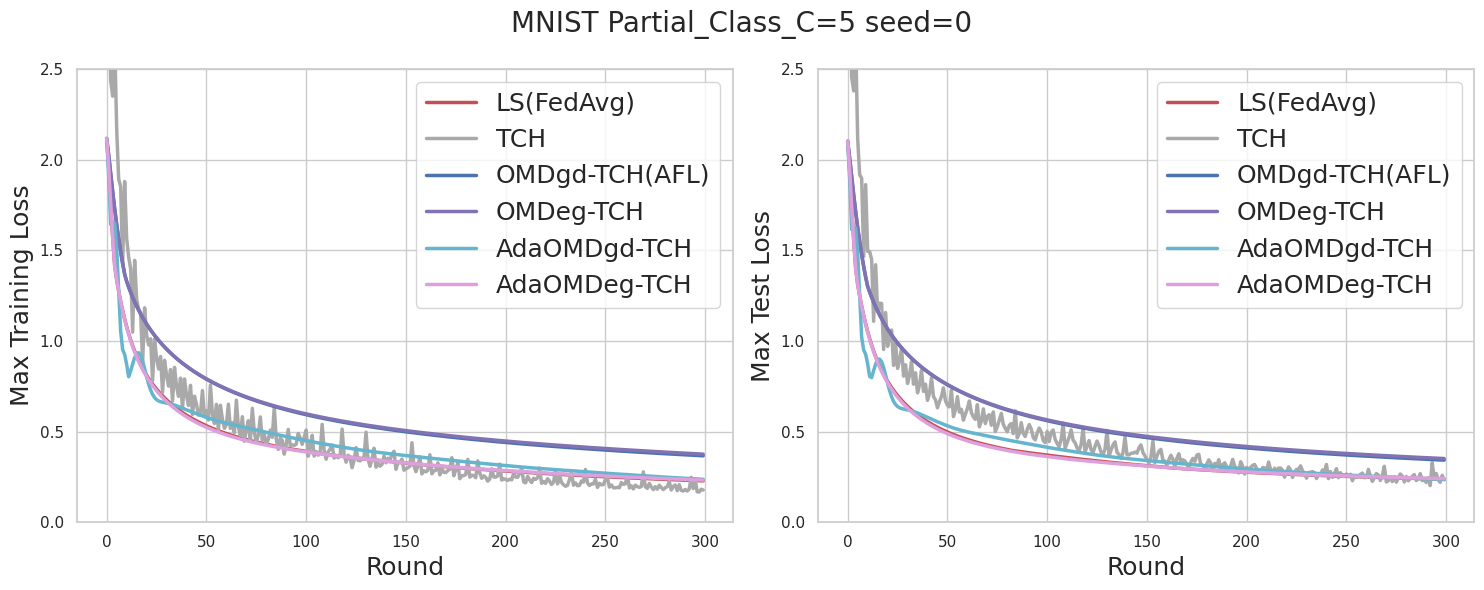

In [34]:
plot_curves('MNIST', 'partial_class_ni5', [0], 
            ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.1', 'AFL_new_llr1.0', 'AFLeg_new_llr0.03'])

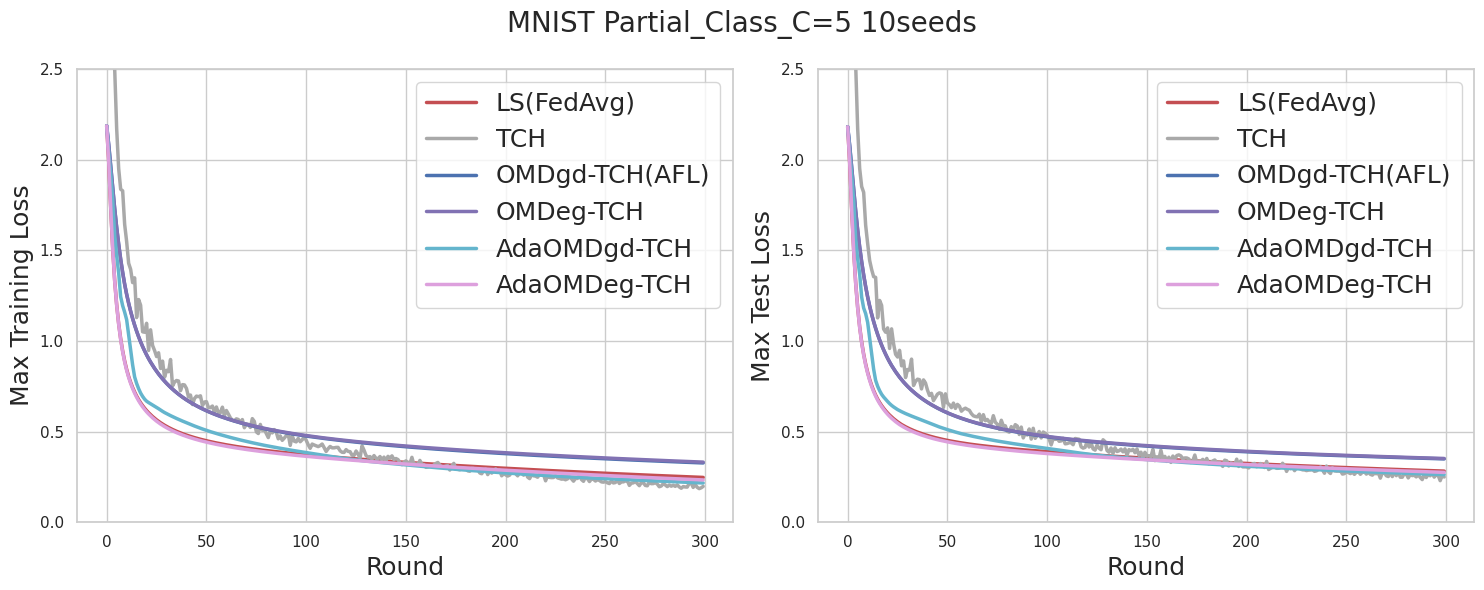

In [35]:
plot_curves('MNIST', 'partial_class_ni5', seeds, 
            ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.1', 'AFL_new_llr1.0', 'AFLeg_new_llr0.03'])

### CIFAR10

#### Rotation

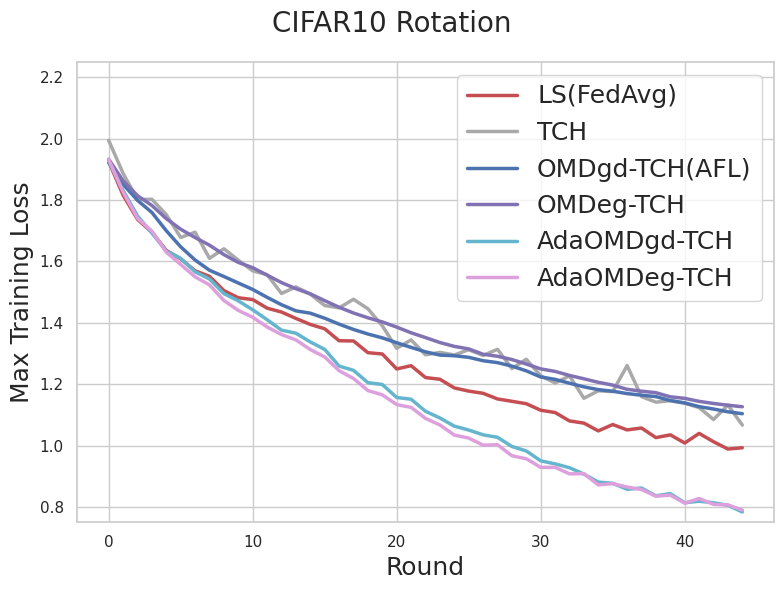

In [6]:
plot_train_only('CIFAR10', 'rotation', [0], 
            ['FedAvg', 'Tche', 'AFL_llr1.0', 'AFLeg_llr1.0', 'AFL_new_llr0.03', 'AFLeg_new_llr0.3'], ymin=0.75, ymax=2.25)

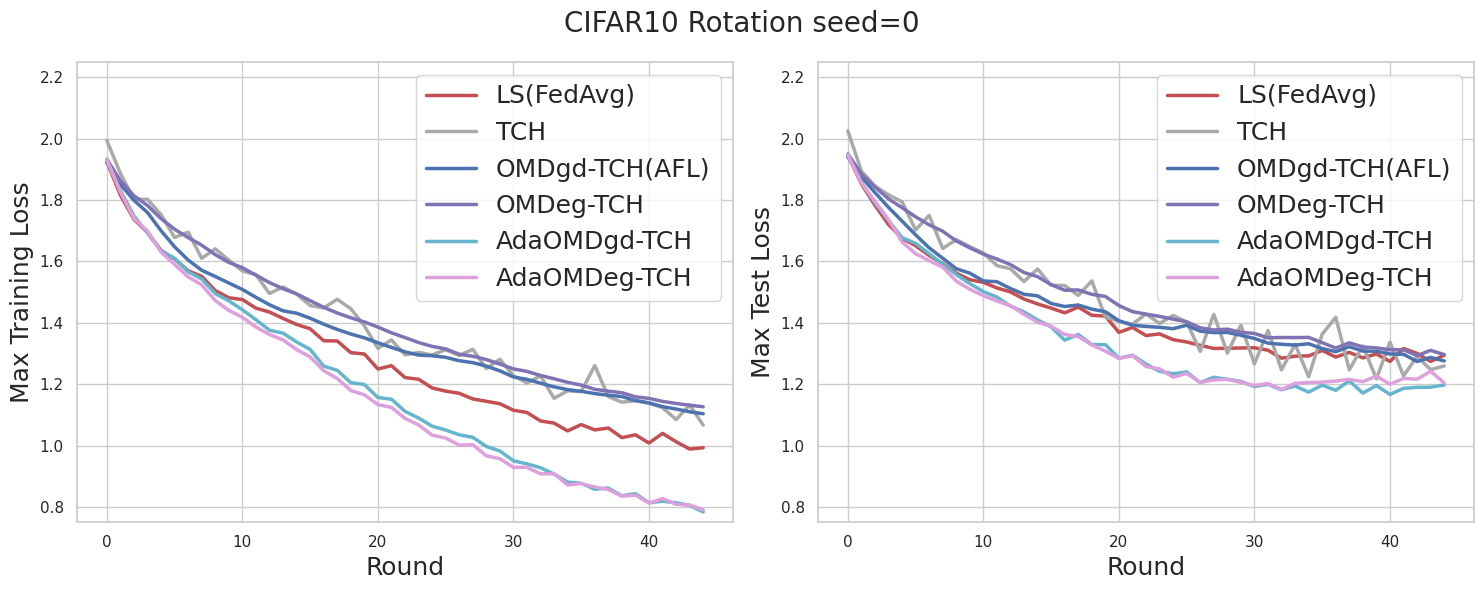

In [13]:
plot_curves('CIFAR10', 'rotation', [0], 
            ['FedAvg', 'Tche', 'AFL_llr1.0', 'AFLeg_llr1.0', 'AFL_new_llr0.03', 'AFLeg_new_llr0.3'], ymin=0.75, ymax=2.25)

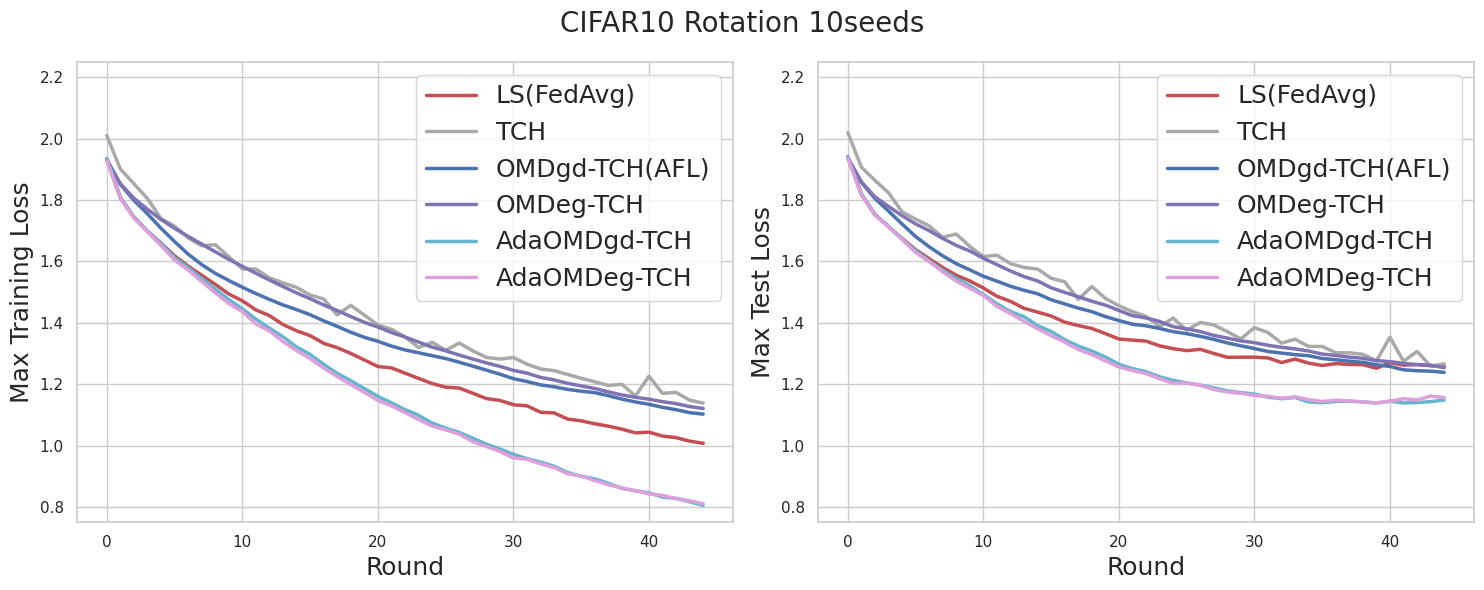

In [14]:
plot_curves('CIFAR10', 'rotation', seeds, 
            ['FedAvg', 'Tche', 'AFL_llr1.0', 'AFLeg_llr1.0', 'AFL_new_llr0.03', 'AFLeg_new_llr0.3'], ymin=0.75, ymax=2.25)

#### Partial_class_ni2

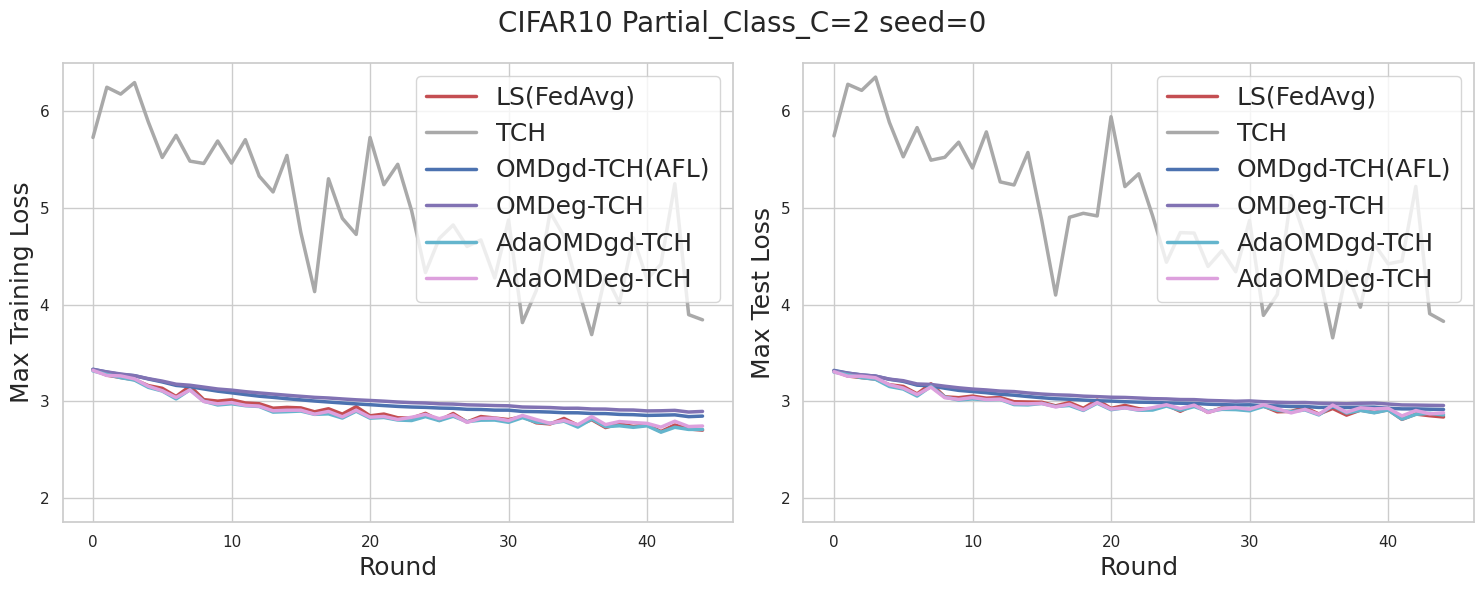

In [36]:
plot_curves('CIFAR10', 'partial_class_ni2', [0], 
            ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.03', 'AFL_new_llr0.003', 'AFLeg_new_llr0.03'], ymin=1.75, ymax=6.5)

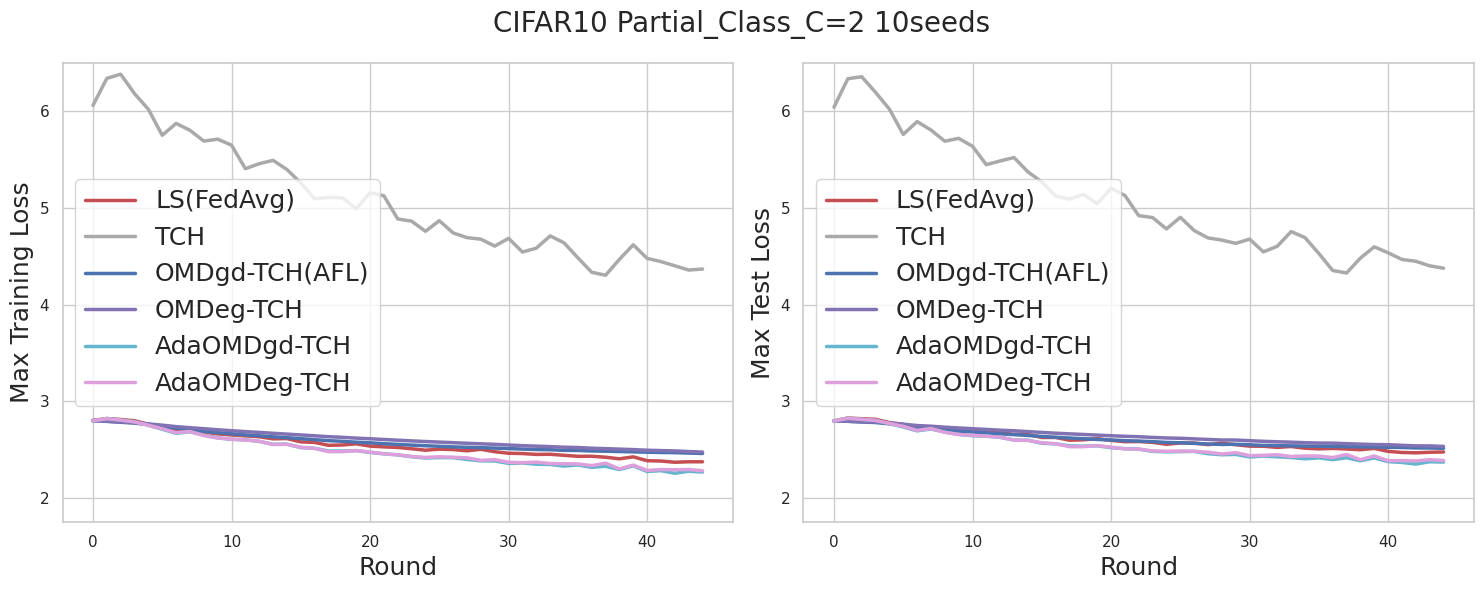

In [37]:
plot_curves('CIFAR10', 'partial_class_ni2', seeds, 
            ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.03', 'AFL_new_llr0.003', 'AFLeg_new_llr0.03'], ymin=1.75, ymax=6.5)

#### Partial_class_ni5

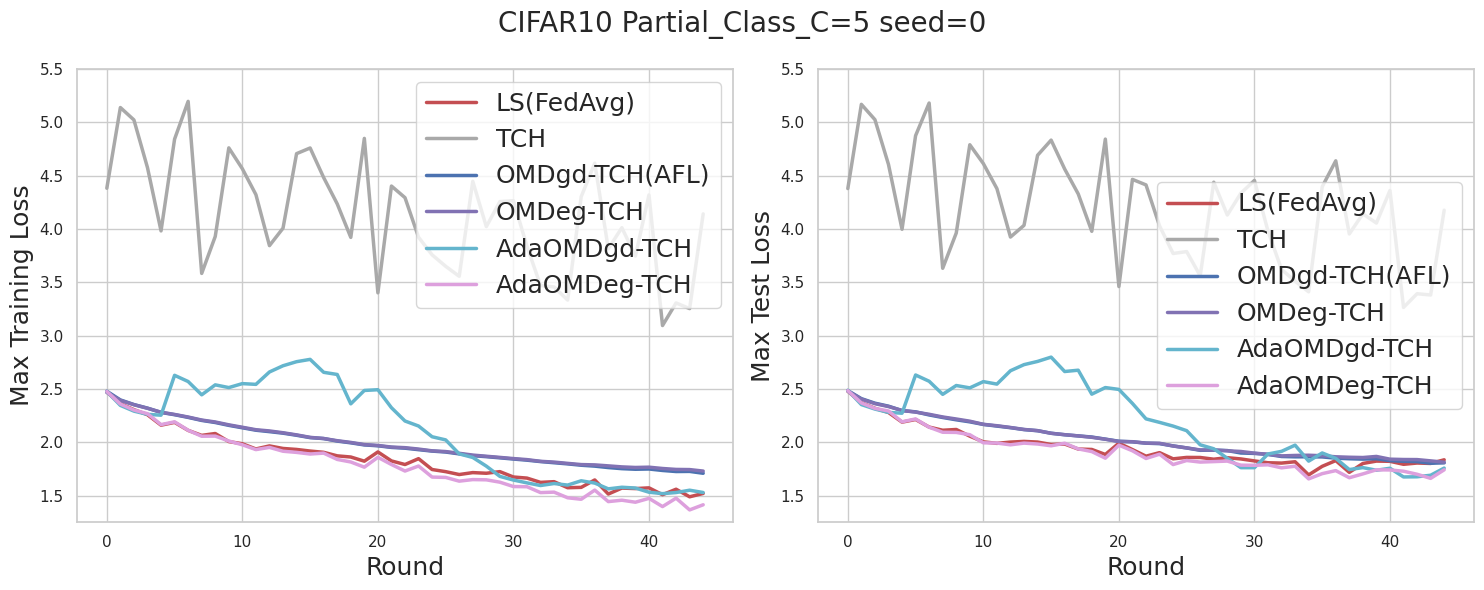

In [8]:
plot_curves('CIFAR10', 'partial_class_ni5', [0], 
            ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.1', 'AFL_new_llr0.3', 'AFLeg_new_llr0.03'], ymin=1.25, ymax=5.5)

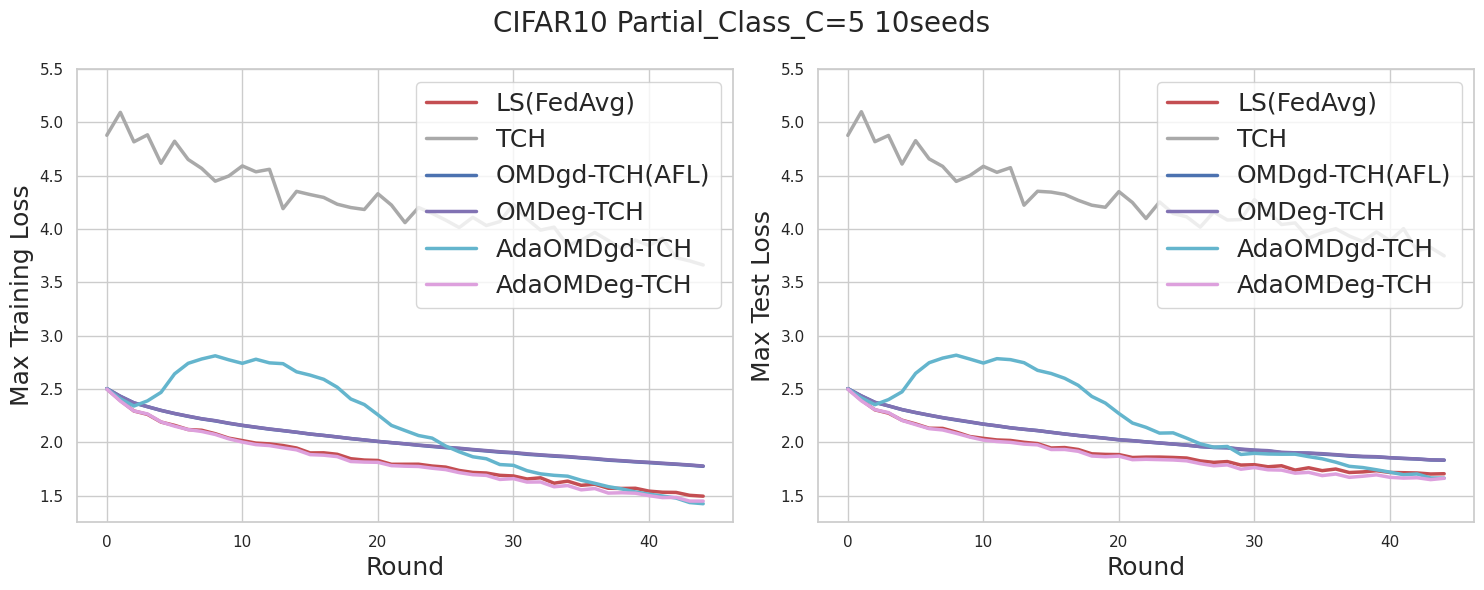

In [9]:
plot_curves('CIFAR10', 'partial_class_ni5', seeds, 
            ['FedAvg', 'Tche', 'AFL_llr0.01', 'AFLeg_llr0.1', 'AFL_new_llr0.3', 'AFLeg_new_llr0.03'], ymin=1.25, ymax=5.5)